# 15 · Gradient boosting with a feature-engineering plan

**Use case.** The graph models learn features from the neighbourhood; a gradient-boosted tree wants them written down as columns. Langsat's GBM lane does that with a **feature-engineering SQL plan** — SQL over the cleaned tables that produces one row per entity with engineered columns, written by the model for your task, or by you in the app — and trains LightGBM on it. This chapter reviews the cleaning plan on a training project, has the model write the feature plan, reads the SQL and its safety checks, trains LightGBM, reads importance, and scores a new review with its related rows.

**Model / lane:** LightGBM on a feature-plan table

**What you will learn**
1. The model menu with a `gbm` family next to `neural`, and how to pick it (`model_key="lightgbm"`)
2. The cleaning plan on a `data_science` project (the training pipeline runs it — review it first)
3. `feature-plan/generate`: the model writes the feature SQL for your task; read the SQL, the columns, the roles, the warnings
4. What the validator refuses — including a leak the correlation check cannot see
5. Editing the SQL yourself: the app's Feature Engineering panel; why a key is refused there
6. Train LightGBM; the engine fields on the model row; feature importance
7. Predict from a new row: a GBM model scores values, and a plan that joins related tables needs them inline (`related_data`)

**What this costs.** one GBM training run (a few minutes; the estimate is reserved and unused minutes refunded), one feature-plan generation (1,000 credits — a model call, refunded on any failure) and a prediction at 50 credits.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
plan = ls.me()["tier"]
menu = ls.request("GET", f"/tiers/{plan}/models", params={"mode": "relational"})
pd.DataFrame(menu["models"])

,key,label,family
0,sage_baseline,Baseline,neural
1,sage_full,SAGE,neural
2,gatv2_full,GAT,neural
3,gin,GIN,neural
4,lightgbm,LightGBM,gbm


## 1 · The project and the task

The same three tables; a `data_science` project. The task is defined first — the feature plan is written *for* a task (its entity, its target, its time column).

In [3]:
p = get_or_create_project(ls, "gbm", kind="data_science")
before = credits_used(ls)
cfg = p.refresh().data.get("task_config")
if not cfg:
    job = p.tasks.define("Predict the rating a review gives, from the review text, its summary, the product and the customer",
                         task_type="supervised", subtask_type="regression").wait(timeout=600)
    cfg = p.refresh().data.get("task_config")
cfg = json.loads(cfg) if isinstance(cfg, str) else cfg
print({k: cfg.get(k) for k in ("task_type", "entity_table", "target_col", "text_embed_columns")})

created project 0613fe4c-8ba8-4082-a131-e25a3164f2b4 (amazon-reviews-gbm, data_science)
uploading ['customer.csv', 'product.csv', 'review.csv'] …


   customer.csv: 9,821 rows × 2 columns → table 'customer'
   product.csv: 8,607 rows × 6 columns → table 'product'
   review.csv: 10,000 rows × 7 columns → table 'review'
detecting schema (primary keys, foreign keys, time column) …


project ready: status=schema_done · type=data_science · files=['customer.csv', 'product.csv', 'review.csv']


{'task_type': 'regression', 'entity_table': 'review', 'target_col': 'rating', 'text_embed_columns': {'review': ['review_text', 'summary'], 'product': ['description', 'title']}}


## 2 · The cleaning plan, on a training project

A `data_science` project has no separate clean step — the training pipeline runs the cleaning plan — but the plan is there to review and change exactly as in chapter 14. The brand and category fixes from that chapter are saved here too, so the feature SQL below sees author names and real categories.

In [4]:
pl = p.cleaning.plan()
print("status:", pl["status"], "· transforms:", sum(1 for t in pl["plan"]["tables"].values() for c in t["columns"].values() if c["action"] == "transform"))
saved = p.cleaning.save({"product": {"columns": {
    "brand": {"action": "transform", "ops": [{"op": "regexp_replace", "params": {"pattern": "^Visit Amazon's (.*) Page$", "replacement": "\\1"}, "reason": "the author's name"}, {"op": "trim", "params": {}}]},
    "category": {"action": "transform", "ops": [{"op": "null_if_in", "params": {"values": ["\\N", ""]}}, {"op": "replace", "params": {"find": "&amp;", "replace": "&"}}]}}}})
print("\n".join(l for l in saved["compiled_sql"].splitlines() if "@col:brand" in l))

status: pending_review · transforms: 2


    /*@col:brand*/ TRIM(REGEXP_REPLACE("brand", '^Visit Amazon''s (.*) Page$', '\1', 'g')) AS "brand",


## 3 · Let the model write the feature plan

`POST /feature-plan/generate` asks the model for feature SQL: one row per entity of the task (here a review) with engineered columns — text lengths and lexicon hits, product and customer attributes, counts over their other reviews — each with a **role** (`static`, `past_derived`, `known_future`, `key`). It costs 1,000 credits, runs as a job, and lands as `status: ready`. With a key this is allowed: the SQL is the platform's own, validated and probed before it is stored.

The validator runs every plan against a sample and refuses what would fool the model: a window that includes the row being predicted, a column that *is* the label, a feature built out of the row id, a column the cleaning step drops — and, on a task like this one with no time order, **any use of the target column in a feature**. The tempting "mean rating of the product's *other* reviews" is `(sum − own rating) / (n − 1)`: inside a product that is a straight line in the row's own rating, and a tree model reads the label straight off it. This chapter's first draft had exactly that column, scored R² 0.95, and put 62 % of its importance on it — which is what a leak looks like.

In [5]:
fp = ls.request("GET", f"/projects/{p.id}/feature-plan")
print("feature plan:", fp["status"], "· generation enabled:", fp["generation_enabled"], "· cost:", fp.get("generation_cost_credits"), "credits")
if fp["status"] in ("none", "failed"):
    fp = ls.request("POST", f"/projects/{p.id}/feature-plan/generate",
                    json={"goal": "features that explain a review's rating: text length and tone, the product's and the customer's other reviews (never their ratings), recency"})
    import time
    while fp["status"] == "generating":
        time.sleep(5)
        fp = ls.request("GET", f"/projects/{p.id}/feature-plan/status/{fp['job_id']}")
print("status:", fp["status"], "· origin:", fp.get("origin"), "· columns:", len(fp["columns"]), "· error:", fp.get("error"))
print("roles:", pd.Series(fp["roles"]).value_counts().to_dict())
for w in fp["warnings"][:2]:
    print("warning:", w[:300])
print(fp["sql"][:1800])

feature plan: none · generation enabled: True · cost: 1000 credits


status: ready · origin: llm · columns: 51 · error: None
roles: {'static': 31, 'past_derived': 19, 'key': 1}
-- LANGSAT_FEATURE_FORMAT: v1-duckdb-sql
WITH r AS (
  SELECT __row_id__, customer_id, product_id, verified, review_text, summary,
         CAST(review_time AS TIMESTAMP) AS rt
  FROM review
),
prod AS (
  SELECT product_id,
         COUNT(*) AS n_rev,
         COUNT(DISTINCT customer_id) AS n_cust,
         AVG(CAST(verified AS DOUBLE)) AS ver_rate,
         AVG(LENGTH(COALESCE(review_text,''))) AS avg_len,
         MIN(CAST(review_time AS TIMESTAMP)) AS first_t,
         MAX(CAST(review_time AS TIMESTAMP)) AS last_t
  FROM review GROUP BY product_id
),
cust AS (
  SELECT customer_id,
         COUNT(*) AS n_rev,
         COUNT(DISTINCT product_id) AS n_prod,
         AVG(CAST(verified AS DOUBLE)) AS ver_rate,
         AVG(LENGTH(COALESCE(review_text,''))) AS avg_len,
         MIN(CAST(review_time AS TIMESTAMP)) AS first_t,
         MAX(CAST(review_time AS TIMESTAMP)) AS last_t
 

## 4 · Editing the SQL yourself

The plan is SQL, so you can change it — add a column, drop one, change a window — in the app's **Feature Engineering** panel: preview runs it on a sample (columns, roles, warnings) and Save stores it with `origin: user`; a stale plan (the schema or cleaning changed after it was written) is refused at train time, before a box boots. From an API key that door is closed, on purpose: SQL a person typed runs on the machine that trains your data, and a key can be a script, a CI job, a leaked file. The refusal is typed.

In [6]:
from langsat import errors
edited = fp["sql"].replace("FROM", "FROM", 1)             # any hand-written text, even unchanged, is a person's SQL to the API
try:
    ls.request("PUT", f"/projects/{p.id}/feature-plan", json={"sql": edited})
except errors.NeedsUserSession as e:
    print("NeedsUserSession ·", e.status, e.code, "·", str(e.message)[:160])

NeedsUserSession · 403 needs_user_session · This action is only available to a signed-in user, not to an API key.


## 5 · Train LightGBM

`model_key="lightgbm"` selects the GBM lane. The run reads the cleaned tables, materialises the feature plan (its columns are added to the lane's own per-entity aggregates), runs a hyper-parameter search with early stopping on the validation split and writes the same model row as the neural lane — plus `engine == "gbm"`, the library, and `n_features`, the width of the frame it trained on. No text embeddings here: the GBM lane sees the text only through what the plan computes from it (lengths, lexicon hits), which is the honest reason its number sits below the graph model's.

In [7]:
from _common import wait_for_training, known_models
model = next((m for m in project_models(p) if m.get("metrics") and (m.get("engine") == "gbm" or m.get("model_type") == "lightgbm")), None)
if model is None:
    minutes = int(p.estimates()["train"]["suggested_minutes"]) + 2
    known = known_models(p)
    p.train(model_key="lightgbm", max_training_min=minutes)
    model = wait_for_training(p, known_model_ids=known)
hp = {k: model.get(k) for k in ("engine", "lib", "lib_version", "n_features")}
print(model["version_label"], model["model_type"], "·", hp)
show(model["metrics"], keys=("mae", "rmse", "r2", "spearman"))
print("read these against chapters 12–13 (graph MAE 0.476 / R² 0.48, FT-Transformer 0.471 / 0.33): a number far beyond them is a leak, not a win")

[   0s] cleaning · claiming · 0.0% · model None


[  21s] training · complete · 100.0% · model training


[  41s] training · loading_data · 0.0% · model training


[ 351s] training · training_epoch · 60.0% · model training


[ 422s] ready · complete · 100.0% · model ready
v1 lightgbm · {'engine': 'gbm', 'lib': 'lightgbm', 'lib_version': '4.5.0', 'n_features': 58}
  r2                     0.3634
  mae                    0.5348
  rmse                   0.7939
  spearman               0.563
read these against chapters 12–13 (graph MAE 0.476 / R² 0.48, FT-Transformer 0.471 / 0.33): a number far beyond them is a leak, not a win


always-mean baseline MAE 0.770 · LightGBM MAE 0.535


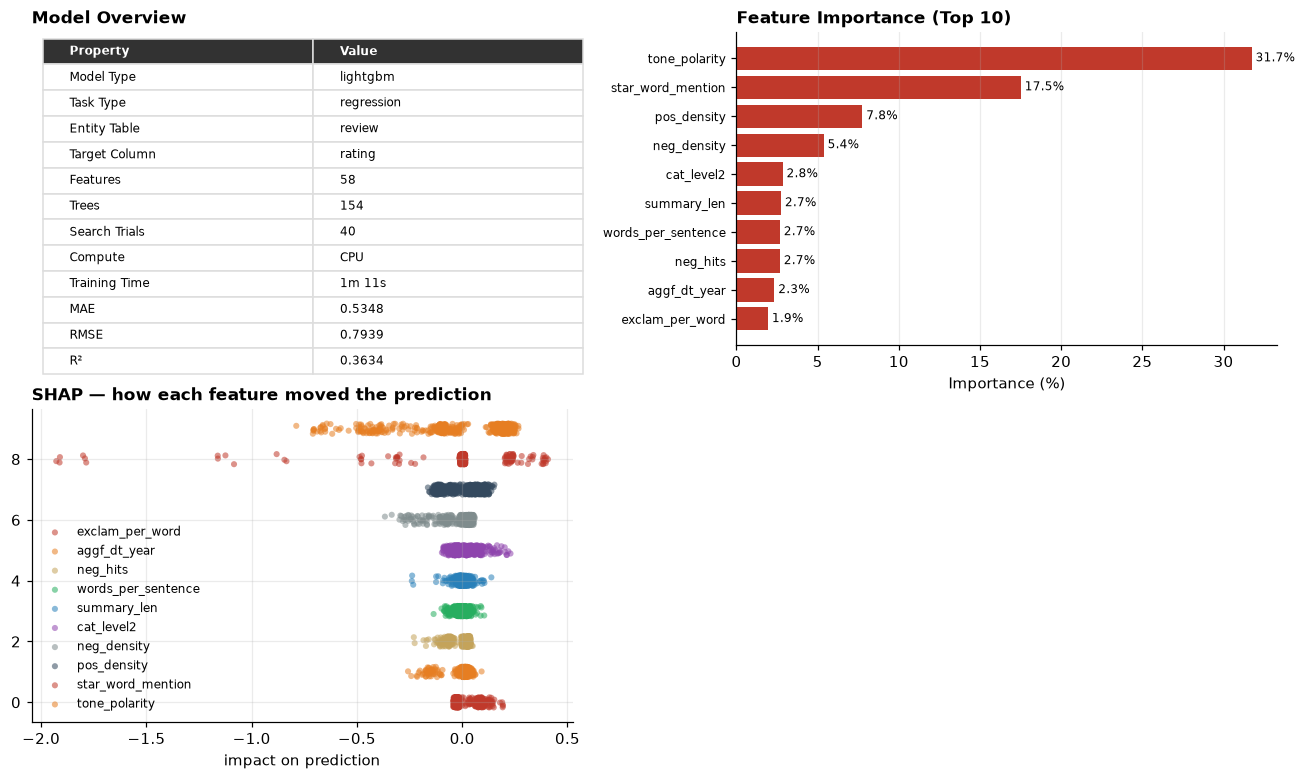

In [8]:
from _common import DATA_DIR
review = pd.read_csv(DATA_DIR / "review.csv")
print(f"always-mean baseline MAE {(review['rating'] - review['rating'].mean()).abs().mean():.3f} · LightGBM MAE {model['metrics']['mae']:.3f}")
fig(viz.model_dashboard(p, cols=2))

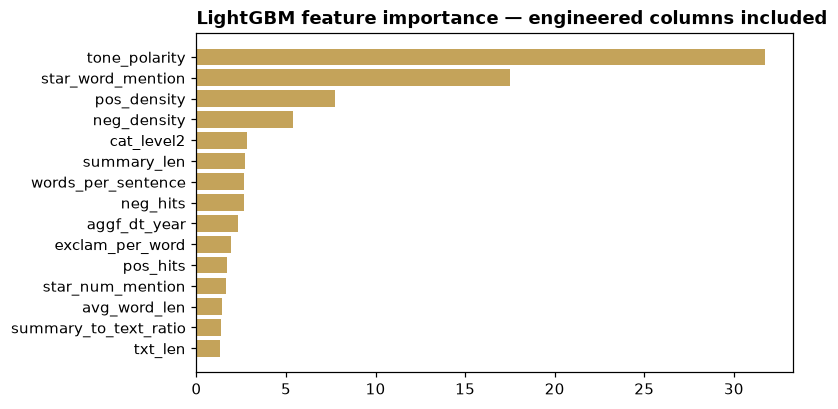

In [9]:
imp = p.models.importance(model["model_id"])
feats = imp.get("features") or imp
top = pd.DataFrame(feats[:15], columns=["feature", "importance"]) if isinstance(feats, list) else pd.Series(feats).sort_values(ascending=False).head(15).rename_axis("feature").reset_index(name="importance")
import matplotlib.pyplot as plt
f, ax = plt.subplots(figsize=(7, 4)); ax.barh(top["feature"][::-1], top["importance"][::-1], color="#c4a35a"); ax.set_title("LightGBM feature importance — engineered columns included", loc="left", fontweight="bold"); fig(f)

## 6 · Predict from a new row

A GBM model predicts from **feature values**, not from a stored id — there is no graph to look a row up in — so `/predict` takes `mode="inductive"` with the row. And because this plan joins the product and the customer, their rows come along **inline** in `related_data` (the plan's SQL runs over exactly what you send: the one review, its product, its customer). The feature schema names the entity columns the plan reads; `review_time` is among them even though it is the time column.

In [10]:
schema = ls.predict.model(model["model_id"])
print("data_mode:", schema["data_mode"], "· model:", schema["model_type"], "· required:", schema["required_features"])
row = {"review_text": "Arrived on time, exactly as described. The kids loved it and we read it twice the first night.",
       "summary": "Great buy", "verified": 1, "review_time": "2018-09-01T00:00:00", "product_id": 246851, "customer_id": 1474411}
related = {"product": [{"product_id": 246851, "category": "Books|Children's Books", "brand": "E. B. White", "title": "Charlotte's Web",
                        "description": "A classic story of friendship on a farm.", "price": 8.99}],
           "customer": [{"customer_id": 1474411, "customer_name": "Kindle Customer"}]}
out = ls.predict.predict(model_id=model["model_id"], mode="inductive", features=row, related_data=related)
print("predicted rating:", round(out["result"]["prediction"], 2), "· model:", out["version_label"], "· mode:", out["mode"])
if out.get("warnings"): print("warnings:", out["warnings"][:2])

data_mode: tabular · model: lightgbm · required: ['customer_id', 'product_id', 'review_text', 'summary', 'verified']


predicted rating: 4.74 · model: v1 · mode: inductive
warnings: [{'feature': 'customer_id', 'type': 'new_category', 'value': '1474411', 'message': "'customer_id' value '1474411' not in training categories"}, {'feature': 'product_id', 'type': 'new_category', 'value': '246851', 'message': "'product_id' value '246851' not in training categories"}]


In [11]:
charged = credits_used(ls) - before
save_metrics(".", {"notebook": "15_gbm_feature_plan", "task": "regression · LightGBM on a feature-engineering SQL plan", "model": model.get("model_type"),
                   "project_id": p.id, "model_id": model["model_id"], "training_duration_sec": model.get("training_duration_sec"), "credits_charged_this_run": charged,
                   "headline": {"mae": model["metrics"].get("mae"), "rmse": model["metrics"].get("rmse"), "r2": model["metrics"].get("r2"),
                                "n_features": hp.get("n_features"), "plan_columns": len(fp["columns"]), "feature_plan_origin": fp.get("origin"),
                                "predicted_rating": round(out["result"]["prediction"], 3)}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [14 · The cleaning plan](../14_cleaning_plan/) — the same plan on an analysis project
- [13 · Choose your model](../13_choose_your_model/) — the neural menus this lane sits beside
- [08 · Predict API](../08_predict_api_and_monitoring/) — serving, monitoring, alerts